In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
cwd = Path('.')

In [19]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path, index_col=0)
data_len = int(len(data) * 10 / 12)
data = data.drop(data[data["position"] == "team"].index)

/tmp/ipykernel_16203/2482187797.py:2: DtypeWarning: Columns (0: league) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path, index_col=0)


In [20]:
# One row per game: Blue side only, deduplicate on gameid
draft_df = (
    data[
        data["side"] == "Blue"
    ]
    .drop_duplicates(subset="gameid")
    [["gameid", "ban1", "ban2", "ban3", "ban4", "ban5",
      "pick1", "pick2", "pick3", "pick4", "pick5", "result"]]
    .dropna(subset=["ban1","ban2","ban3","ban4","ban5",
                    "pick1","pick2","pick3","pick4","pick5","result"])
    .reset_index(drop=True)
)

feature_cols = ["ban1","ban2","ban3","ban4","ban5",
                "pick1","pick2","pick3","pick4","pick5"]

# Consistent label encoding across all columns so same champion -> same integer
all_champs = pd.unique(draft_df[feature_cols].values.ravel())
le = LabelEncoder().fit(all_champs)

draft_encoded = draft_df.copy()
for col in feature_cols:
    draft_encoded[col] = le.transform(draft_df[col])

X = draft_encoded[feature_cols].values
y = draft_encoded["result"].astype(int).values

print(f"Games: {len(X)},  Features: {X.shape[1]},  Class balance: {y.mean():.2%} wins")
draft_encoded[feature_cols + ["result"]].head()

Games: 9641,  Features: 10,  Class balance: 53.91% wins


,ban1,ban2,ban3,ban4,ban5,pick1,pick2,pick3,pick4,pick5,result
0,148,123,24,54,128,78,53,70,44,38,0
1,56,12,123,2,167,143,54,47,13,105,1
2,46,70,47,128,94,24,123,4,12,0,0
3,56,113,148,34,5,150,123,32,88,51,0
4,51,98,110,102,105,10,12,18,54,149,1


In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

EMBED_DIM  = 32
#HIDDEN     = [256, 128, 64]
HIDDEN     = [128, 64, 32]
DROPOUT    = 0.3
BATCH_SIZE = 256
EPOCHS     = 50
LR         = 1e-3
SEED       = 42

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

class DraftDataset(Dataset):
    """Each sample randomly shuffles bans (cols 0-4) and picks (cols 5-9)
    independently, so the model sees every permutation across epochs."""
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            x[:5] = x[torch.randperm(5)]   # shuffle bans
            x[5:] = x[5:][torch.randperm(5)]  # shuffle picks
        return x, self.y[idx]

train_loader = DataLoader(DraftDataset(X_train, y_train, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(DraftDataset(X_test,  y_test,  augment=False),
                          batch_size=BATCH_SIZE)

print(f"Train: {len(X_train)}  Test: {len(X_test)}  Device: {device}")

Train: 7712  Test: 1929  Device: cpu


In [22]:
class DraftNet(nn.Module):
    def __init__(self, num_champs, embed_dim, hidden_sizes, dropout):
        super().__init__()
        # Shared embedding: same champion gets same vector regardless of slot
        self.embed = nn.Embedding(num_champs, embed_dim)

        layers = []
        in_dim = 10 * embed_dim  # 10 slots concatenated
        for h in hidden_sizes:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (batch, 10)  ->  embed each slot  ->  (batch, 10, embed_dim)
        emb = self.embed(x).flatten(1)   # (batch, 10*embed_dim)
        return self.mlp(emb).squeeze(1)  # (batch,)

num_champs = len(le.classes_)
model = DraftNet(num_champs, EMBED_DIM, HIDDEN, DROPOUT).to(device)
print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

DraftNet(
  (embed): Embedding(171, 32)
  (mlp): Sequential(
    (0): Linear(in_features=320, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parameters: 57,377


In [23]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(yb)
        correct += ((logits > 0) == yb.bool()).sum().item()
        total += len(yb)
    scheduler.step()

    # --- eval ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            val_loss += criterion(logits, yb).item() * len(yb)
            val_correct += ((logits > 0) == yb.bool()).sum().item()
            val_total += len(yb)

    history["train_loss"].append(train_loss / total)
    history["train_acc"].append(correct / total)
    history["val_loss"].append(val_loss / val_total)
    history["val_acc"].append(val_correct / val_total)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | "
              f"train loss {history['train_loss'][-1]:.4f} acc {history['train_acc'][-1]:.3f} | "
              f"val loss {history['val_loss'][-1]:.4f} acc {history['val_acc'][-1]:.3f}")

Epoch  10 | train loss 0.6914 acc 0.537 | val loss 0.6858 acc 0.553
Epoch  20 | train loss 0.6855 acc 0.551 | val loss 0.6850 acc 0.541
Epoch  30 | train loss 0.6832 acc 0.558 | val loss 0.6840 acc 0.553
Epoch  40 | train loss 0.6818 acc 0.561 | val loss 0.6835 acc 0.551
Epoch  50 | train loss 0.6814 acc 0.564 | val loss 0.6836 acc 0.552


              precision    recall  f1-score   support

        Loss       0.53      0.29      0.37       889
         Win       0.56      0.78      0.65      1040

    accuracy                           0.55      1929
   macro avg       0.54      0.53      0.51      1929
weighted avg       0.54      0.55      0.52      1929

ROC-AUC: 0.5674


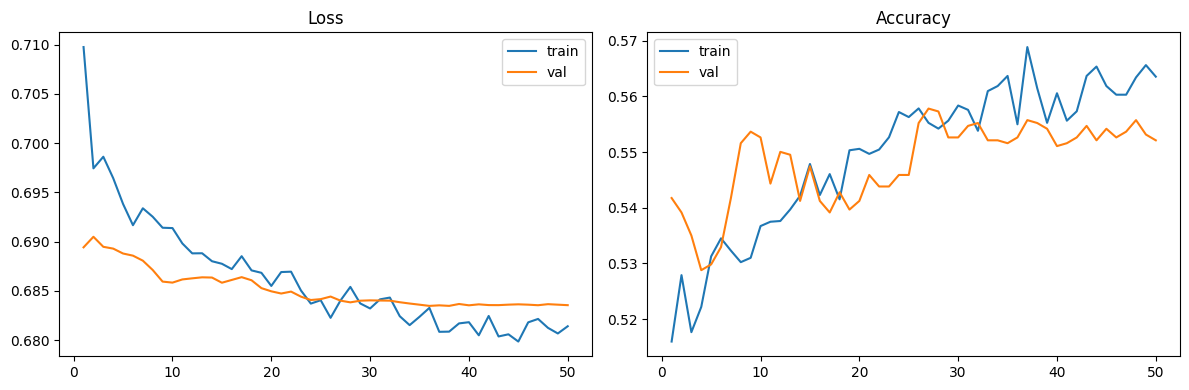

In [24]:
from sklearn.metrics import classification_report, roc_auc_score

model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_logits.append(model(xb.to(device)).cpu())
        all_labels.append(yb)

logits_np = torch.cat(all_logits).numpy()
labels_np = torch.cat(all_labels).numpy()
preds_np  = (logits_np > 0).astype(int)

print(classification_report(labels_np, preds_np, target_names=["Loss", "Win"]))
print(f"ROC-AUC: {roc_auc_score(labels_np, logits_np):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS + 1)
axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"],   label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()